In [1]:
import os
import sys
import time
import glob
import argparse
import traceback
#! pip install ascii
#from ascii import header, footer
from datetime import datetime, timezone
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo

import json
import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

from scipy.fft import rfft, rfftfreq
from scipy.stats import beta

In [2]:
# Get the sum waveform for a given event and units
def get_sum_waveform(waveform, units='ADC16', mask=None, clip=True):
    # waveform shape: (n_events, n_adcs, n_channels, n_samples)
    if mask is not None:
        waveform = waveform[mask]
    if units == 'ADC14':
        waveform = waveform / adc14_16
    elif units == 'V':
        waveform = adc16_to_voltage(waveform)
    elif units != 'ADC16':
        raise ValueError("Units must be 'ADC14', 'ADC16', or 'V'.")
    # sum over samples axis
    sum_waveform = np.sum(waveform, axis=0)
    # clip the waveform if requested to mimic non-baselined oscilloscope limit
    if clip:
        sum_waveform = np.clip(sum_waveform, 0, 8192*4 - 1)
    return sum_waveform

In [21]:
# Plot the sum waveform per EPCB for a single event
def plot_sum_waveform(waveform, units='ADC16', i_evt=0, output_name='sum_waveform.pdf'):
    # waveform shape: (n_events, n_adcs, n_channels, n_samples)
    n_epcbs = int(len(channels) // 6)
    n_adcs = waveform.shape[0]
    n_samples = waveform.shape[-1]
    nrows = n_adcs * (n_epcbs // 2)
    ncols = 2
    _, axes = plt.subplots(nrows, ncols, figsize=(20, 2 * nrows), sharex=True)

    # Ensure axes is always 2D
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(n_adcs):
        for j in range(n_epcbs):
            idx = i * (n_epcbs // 2) + (j // 2)
            tt_idx = j % 2
            channels_list = channels[j * 6:(j + 1) * 6]
            # Extract waveform for this event, ADC, and EPCB channels
            #epcb_signals = np.sum((np.max(waveform[i, channels_list, :], axis=-1) > 3e2), axis=-1)
            #signal_mask = np.where(epcb_signals >= 2)[0]
            #if len(signal_mask)==0:
            epcb_waveform = waveform[i, channels_list, :]
            #else:
            #    epcb_waveform = waveform[signal_mask[0], i, channels_list, :]
            # loop over channels
            for ch in range(len(channels_list)):
                axes[idx, tt_idx].plot(epcb_waveform[ch, :], label=f'Channel {channels_list[ch]}')
            # plot total
            sum_wvfm = get_sum_waveform(epcb_waveform, units=units)
            # set title
            axes[idx, tt_idx].set_title(f'Event {i_evt} - Non-beam trigger timing')
            axes[idx, tt_idx].plot(sum_wvfm, color='black', alpha=0.5, label='Sum ADC')
            axes[idx, tt_idx].set_title(f'ADC {i} - EPCB {j} summed waveforms')
            axes[idx, tt_idx].set_ylabel(f'{units} counts')
            axes[idx, tt_idx].legend(loc='upper right', fontsize='small')
            axes[idx, tt_idx].grid(True)
            axes[idx, tt_idx].set_xlim(0, n_samples)
            axes[idx, tt_idx].set_ylim(-5000, 38000)
    axes[-1, 0].set_xlabel('Samples/ time (ticks)')
    axes[-1, 1].set_xlabel('Samples/ time (ticks)')
    plt.tight_layout()
    plt.show()
    # save as pdf
    #output_pdf = f"{args.tmp_dir}/{output_name}"
    #with PdfPages(output_pdf) as pdf:
        #pdf.savefig()
        #plt.close()

In [39]:
def tag_dark_counts(N_Files, START=0, INPUT_name=None, adc_list=None, ticks=600):

     file_num = 0
     dark_count_wvfm = np.zeros((8,64,ticks), dtype=np.int64)
     #peak_value = np.zeros((8,64), dtype=np.int64)
     SIPM_CHANNELS = ([4,5,6,7,8,9] + \
                     [10,11,12,13,14,15] + \
                     [20,21,22,23,24,25] + \
                     [26,27,28,29,30,31] + \
                     [36,37,38,39,40,41] + \
                     [42,43,44,45,46,47] + \
                     [52,53,54,55,56,57] + \
                     [58,59,60,61,62,63])

     for Nf in range(N_Files):
          file = f'{INPUT_name}_p{START+file_num}.FLOW.hdf5'

          if file_num < N_Files:
               print('file number:', file_num)
               file_num += 1
               if not os.path.isfile(file):
                    print('NOT A FILE')
                    continue
               else:
                    with h5py.File(file, 'r') as h5:

                         size_bytes = os.path.getsize(file)
                         size_gb = size_bytes / (1024 ** 3)
                         print(f"File size: {size_gb:.2f} GB")

                         MULT = int(size_gb // 1)
                         print(f"Using MULT = {MULT} for data reduction.")
                         if MULT < 1:
                              MULT = 1
                              print(f"Using MULT = {MULT} for data reduction.")

                         offbeam_wvfm_v1 =  h5['light/wvfm/data']['samples'][::MULT,:,:,:] / 4
                         offbeam_wvfm_v2 =  offbeam_wvfm_v1- offbeam_wvfm_v1[:,:,:,:50].mean(axis=-1, keepdims=True)
                         del offbeam_wvfm_v1
                         if adc_list is None:
                              adc_list = [0,1,2,3,4,5,6,7]
                         for adc in adc_list:
                              CHANNEL_LIST = [6,10,24,26,36,42,52,58]
                              for ch in CHANNEL_LIST:
                              #for ch in SIPM_CHANNELS:
                                   #mask = np.where(np.ptp(offbeam_wvfm_v2[:, adc, ch, :], axis=-1) < 1e3)[0]
                                   mask = np.argmax(np.max(offbeam_wvfm_v2[:, adc, ch, :], axis=-1))
                                   #if len(mask) == 0:
                                   #     del mask
                                   #     continue
                                   #else:
                                   #max_idx = np.argmax(np.max(offbeam_wvfm_v2[mask, adc, ch, :], axis=-1))
                                   max_value = np.max(offbeam_wvfm_v2[mask, adc, ch, :], axis=-1)

                                   for e_ch in range(6):
                                        dark_count_wvfm[adc, ch+e_ch, :] += np.array(offbeam_wvfm_v2[mask, adc, ch+e_ch, :], dtype=np.int16)
                                   del mask
                                   del max_value

                         del offbeam_wvfm_v2
     return dark_count_wvfm

In [40]:
# Frequency regions of interest (MHz) and window width (MHz)
vlist = [0.5e6, 1.8e6, 4.6e6, 7.1e6, 8.5e6, 10e6, 11.5e6, 19e6, 20e6, 25e6, 30e6]
window = 0.4e6

# Channel mapping: select channels 4-15 in each group of 16
channels = []
for group_start in range(0, 64, 16):
    channels.extend(range(group_start + 4, min(group_start + 16, 64)))

# Load channel status (0 = good, nonzero = bad)
channel_status_csv = '/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/Commissioning_Code/2x2_LRS_OperatingScripts/LowLevel_Commissioning/channel_status.csv'
cs = None  # default if load fails

try:
    cs_df = pd.read_csv(channel_status_csv, header=None)
    cs = cs_df.to_numpy()
    print(f"Channel status loaded successfully from: {channel_status_csv}")
except FileNotFoundError:
    print(f"Channel status file not found, skipping: {channel_status_csv}")
except pd.errors.EmptyDataError:
    print(f"Channel status file is empty: {channel_status_csv}")
except Exception as e:
    print(f"Error loading channel status from {channel_status_csv}: {e}")

Channel status loaded successfully from: /global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/Commissioning_Code/2x2_LRS_OperatingScripts/LowLevel_Commissioning/channel_status.csv


In [41]:
N_FILES = 1
START_p = 0
input_file = '/global/cfs/cdirs/dune/users/ajwhite/FLOW_122025/Run1_July10_v12_JuneEvBuilderFlow_files/mpd_run_hvramp_rctl_105'
ADC_LIST = [0,1,2,3,4,5,6,7]
TICKS = 1000

In [42]:
SIGNAL_OUTPUT = tag_dark_counts(N_Files=N_FILES, START=START_p, INPUT_name=input_file, adc_list=ADC_LIST, ticks=TICKS)

file number: 0
File size: 4.18 GB
Using MULT = 4 for data reduction.


In [43]:
print("SIGNAL_OUTPUT shape:", SIGNAL_OUTPUT.shape)

SIGNAL_OUTPUT shape: (8, 64, 1000)


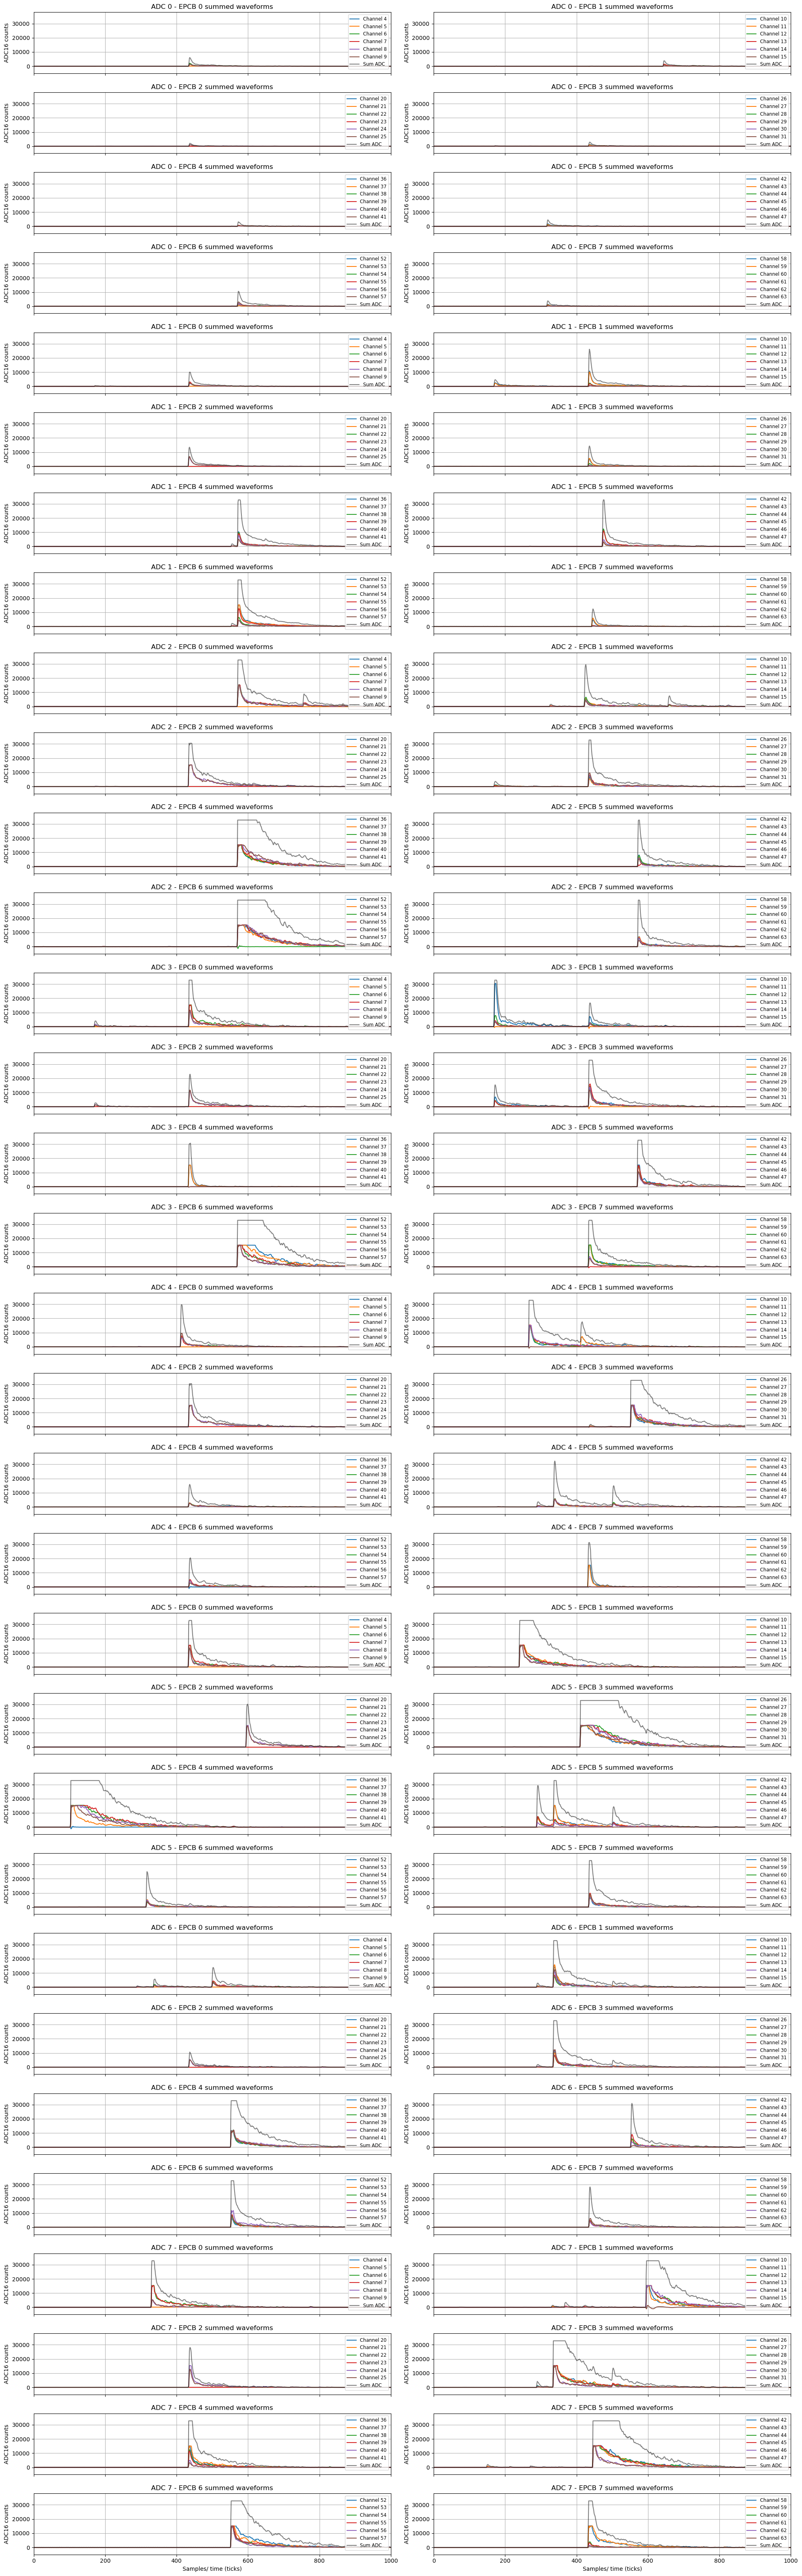

In [44]:
plot_sum_waveform(SIGNAL_OUTPUT, units='ADC16', i_evt=0, output_name='sum_waveform.pdf')